# Linear Regression: Demo

In [3]:
# Start with importing the usual stuff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.model_selection import train_test_split 

pd.options.mode.copy_on_write = True

In [14]:
# This contains some functions written by the authors of the textbook (ISLP)
# we'll be adapting most of the this demo from their material

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

## Set up data

In [15]:
# First we'll read in our data and look quickly at its contents

#Auto = pd.read_csv('../../data/Auto.csv')
Auto = load_data('Auto')
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


In [16]:
# Sometimes it's helpful to look at the list of columns
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [17]:
# What is the data type of each column?
Auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower        int64
weight            int64
acceleration    float64
year              int64
origin            int64
dtype: object

## Review the target variable

In [18]:
# Since we want to predict mpg, let's start by listing all its possible values
np.unique(Auto['mpg'])

array([ 9. , 10. , 11. , 12. , 13. , 14. , 14.5, 15. , 15.5, 16. , 16.2,
       16.5, 16.9, 17. , 17.5, 17.6, 17.7, 18. , 18.1, 18.2, 18.5, 18.6,
       19. , 19.1, 19.2, 19.4, 19.8, 19.9, 20. , 20.2, 20.3, 20.5, 20.6,
       20.8, 21. , 21.1, 21.5, 21.6, 22. , 22.3, 22.4, 22.5, 23. , 23.2,
       23.5, 23.7, 23.8, 23.9, 24. , 24.2, 24.3, 24.5, 25. , 25.1, 25.4,
       25.5, 25.8, 26. , 26.4, 26.5, 26.6, 26.8, 27. , 27.2, 27.4, 27.5,
       27.9, 28. , 28.1, 28.4, 28.8, 29. , 29.5, 29.8, 29.9, 30. , 30.5,
       30.7, 30.9, 31. , 31.3, 31.5, 31.6, 31.8, 31.9, 32. , 32.1, 32.2,
       32.3, 32.4, 32.7, 32.8, 32.9, 33. , 33.5, 33.7, 33.8, 34. , 34.1,
       34.2, 34.3, 34.4, 34.5, 34.7, 35. , 35.1, 35.7, 36. , 36.1, 36.4,
       37. , 37.2, 37.3, 37.7, 38. , 38.1, 39. , 39.1, 39.4, 40.8, 41.5,
       43.1, 43.4, 44. , 44.3, 44.6, 46.6])

In [19]:
# Are there any missing values in there?
# isnull() returns 1s for each NaN, then we can add them up to get the total count of missing values

Auto['mpg'].isnull().sum()

# CAUTION: This isn't foolproof! It won't find missing values that have been coded as 0, -1, 9999, etc.

np.int64(0)

In [ ]:
# Let's create a function that allows us to display a histogram for a variable
# Credit to Hastie and Tibshirani--see their notes for more details on this

def histogram(var):
    n, bins, patches = plt.hist(x=var, bins='auto', color='#0504aa',
                            alpha=0.7, rwidth=0.85)
    plt.grid(axis='y', alpha=0.75)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Frequency of ' + var.name)

In [22]:
histogram(Auto['mpg'])

NameError: name 'histogram' is not defined

## Feature Engineering

### Missing Values

In [23]:
np.unique(Auto['horsepower'])

array([ 46,  48,  49,  52,  53,  54,  58,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98, 100, 102, 103, 105, 107, 108, 110,
       112, 113, 115, 116, 120, 122, 125, 129, 130, 132, 133, 135, 137,
       138, 139, 140, 142, 145, 148, 149, 150, 152, 153, 155, 158, 160,
       165, 167, 170, 175, 180, 190, 193, 198, 200, 208, 210, 215, 220,
       225, 230])

In [24]:
Auto[(Auto['horsepower']=='?')]

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,


In [25]:
# Should we remove those records?
# Auto = Auto[(Auto['horsepower']!='?')]

In [26]:
# Or should we impute the mean value?

# Ok let's calculate the mean value first
int(pd.to_numeric(Auto['horsepower'], errors='coerce').mean())

104

In [27]:
# Now we'll impute the mean into the missing cells
Auto.replace({'horsepower':'?'},'104',inplace=True)

np.unique(Auto['horsepower'])

array([ 46,  48,  49,  52,  53,  54,  58,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98, 100, 102, 103, 105, 107, 108, 110,
       112, 113, 115, 116, 120, 122, 125, 129, 130, 132, 133, 135, 137,
       138, 139, 140, 142, 145, 148, 149, 150, 152, 153, 155, 158, 160,
       165, 167, 170, 175, 180, 190, 193, 198, 200, 208, 210, 215, 220,
       225, 230])

In [28]:
# Convert the horsepower column to numeric

Auto['horsepower'] = pd.to_numeric(Auto['horsepower'])

## Set up structure for modeling

In [29]:
# Identify some predictors and the target

X = Auto[['horsepower', 'weight', 'year']]
y = Auto['mpg']

In [30]:
# Create a column for the intercept in the features matrix

X['intercept'] = np.ones(Auto.shape[0])
X

,horsepower,weight,year,intercept
name,,,,
chevrolet chevelle malibu,130,3504,70,1.0
buick skylark 320,165,3693,70,1.0
plymouth satellite,150,3436,70,1.0
amc rebel sst,150,3433,70,1.0
ford torino,140,3449,70,1.0
...,...,...,...,...
ford mustang gl,86,2790,82,1.0
vw pickup,52,2130,82,1.0
dodge rampage,84,2295,82,1.0


In [31]:
# Create training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=314,
                                                    test_size=0.25,
                                                    shuffle=True) 
Train = pd.merge_ordered(X_train,y_train,left_on=X_train.index,right_on=y_train.index).drop(columns=['key_0'])
Test = pd.merge_ordered(X_test,y_test,left_on=X_test.index,right_on=y_test.index).drop(columns=['key_0'])

In [32]:
# Spot check the train and test sets

print(X_train.head()) 
print(X_train.shape)
print()
print(y_train.head()) 
print(y_train.shape)
print() 
print(X_test.head()) 
print(X_test.shape)
print() 
print(y_test.head())
print(y_test.shape)
print() 
print(Train.head())
print(Train.shape)
print() 
print(Test.head())
print(Test.shape)

                                   horsepower  weight  year  intercept
name                                                                  
hi 1200d                                  193    4732    70        1.0
chevrolet chevelle malibu classic         100    3781    74        1.0
volkswagen type 3                          54    2254    72        1.0
buick opel isuzu deluxe                    80    2155    77        1.0
amc concord                                90    3210    78        1.0
(294, 4)

name
hi 1200d                              9.0
chevrolet chevelle malibu classic    16.0
volkswagen type 3                    23.0
buick opel isuzu deluxe              30.0
amc concord                          19.4
Name: mpg, dtype: float64
(294,)

                                   horsepower  weight  year  intercept
name                                                                  
oldsmobile vista cruiser                  180    4499    73        1.0
toyota celica gt liftback      

In [ ]:
# Look at possible values and spot check for missing entries

print('MPG')
print(np.unique(Train['mpg']))
print('Horsepower')
print(np.unique(Train['horsepower']))
print('Weight')
print(np.unique(Train['weight']))
print('Year')
print(np.unique(Train['year']))

## Simple Linear Regression, Example 1

In [33]:
# Build a linear model where horsepower predicts mpg
# Take note of the p-values

model_hp = sm.OLS(y_train, X_train[['intercept','horsepower']])
results_hp = model_hp.fit()
summarize(results_hp)

,coef,std err,t,P>|t|
intercept,40.0946,0.819,48.980,0.0
horsepower,-0.1569,0.007,-21.166,0.0


In [34]:
# We can also assess the overall fit of the model

print('R^2 on train:',results_hp.rsquared)

R^2 on train: 0.6053947664927444


In [35]:
# Create helper functions for computing the mean squared error

def predict(X, model):
    # the built-in get_prediction tool returns an array, so we need to convert to a dataframe
    predictions_df = pd.DataFrame(model.get_prediction(X).predicted, columns=['y_hat'], index=X.index)
    return predictions_df['y_hat']

def mse(y, y_hat):
    # calculate the residual error for each individual record
    resid = y - y_hat
    # square the residual (hence "squared error")
    sq_resid = resid**2
    # calculate the sum of squared errors
    SSR = sum(sq_resid)
    # divide by the number of records to get the mean squared error
    MSE = SSR / y.shape[0]
    return MSE

In [36]:
# Let's compute the MSE on the training and test sets

predictions_hp_train = predict(X_train[['intercept', 'horsepower']], results_hp)
print('mse train:',mse(y_train, predictions_hp_train))
predictions_hp_test = predict(X_test[['intercept', 'horsepower']], results_hp)
print('mse test:',mse(y_test, predictions_hp_test))

mse train: 24.862742151361818
mse test: 21.4570589666384


In [37]:
# Define a function to draw a line given coefficients [credit to Hastie & Tibshirani]

def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

/var/folders/xk/1rld6vfd1wg4hnmdkv7sx_b00000gn/T/ipykernel_51873/4284870531.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_hp.params[0],
/var/folders/xk/1rld6vfd1wg4hnmdkv7sx_b00000gn/T/ipykernel_51873/4284870531.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results_hp.params[1],


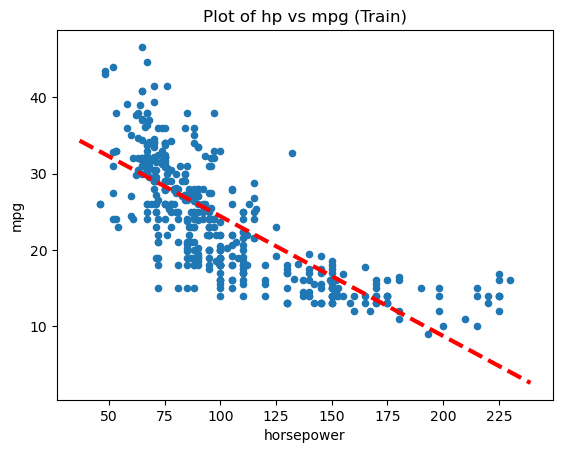

In [38]:
# Plot hp vs mpg on training set

ax = Train.plot.scatter('horsepower', 'mpg')
ax.set_title("Plot of hp vs mpg (Train)")
abline(ax,
       results_hp.params[0],
       results_hp.params[1],
       'r--',
       linewidth=3)

In [ ]:
# Plot hp vs mpg on test set

ax = Test.plot.scatter('horsepower', 'mpg')
ax.set_title("Plot of hp vs mpg (Test)")
abline(ax,
       results_hp.params[0],
       results_hp.params[1],
       'g--',
       linewidth=3)

In [ ]:
# Plot residual error for train set

ax = subplots(figsize=(8,8))[1]
ax.scatter(predictions_hp_train, y_train-predictions_hp_train)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

In [ ]:
# Plot residual error for test set

ax = subplots(figsize=(8,8))[1]
ax.scatter(predictions_hp_test, y_test-predictions_hp_test)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

## Simple Linear Regression, Example 2

In [ ]:
# Build a linear model where weight predicts mpg

model_weight = sm.OLS(y_train, X_train[['intercept','weight']])
results_weight = model_weight.fit()
summarize(results_weight)

In [ ]:
# R^2 for weight model
print('R^2 on train:',results_weight.rsquared)

In [ ]:
# MSE for weight model

predictions_weight_train = predict(X_train[['intercept', 'weight']], results_weight)
print('mse train:',mse(y_train, predictions_weight_train))
predictions_weight_test = predict(X_test[['intercept', 'weight']], results_weight)
print('mse test:',mse(y_test, predictions_weight_test))

In [ ]:
# Plot weight vs mpg on training set

ax = Train.plot.scatter('weight', 'mpg')
ax.set_title("Plot of weight vs mpg (Train)")
abline(ax,
       results_weight.params[0],
       results_weight.params[1],
       'r--',
       linewidth=3)

In [ ]:
# Plot weight vs mpg on test set

ax = Test.plot.scatter('weight', 'mpg')
ax.set_title("Plot of weight vs mpg (Test)")
abline(ax,
       results_weight.params[0],
       results_weight.params[1],
       'g--',
       linewidth=3)

In [ ]:
# Plot residual error for training set

ax = subplots(figsize=(8,8))[1]
ax.scatter(predictions_weight_train, y_train-predictions_weight_train)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

In [ ]:
# Plot residual error for test set

ax = subplots(figsize=(8,8))[1]
ax.scatter(predictions_weight_test, y_test-predictions_weight_test)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

## Simple Linear Regression, Example 3

In [ ]:
# Build a linear model where year predicts mpg



In [ ]:
# Compute the R^2 for year model (on train)



In [ ]:
# Compute the MSE for year model (on train and then on test)



In [ ]:
# Plot year vs mpg (on train)



## Categorical Predictors

In [ ]:
# One potentially useful variable is the name of the vehicle

Auto['name']

In [ ]:
# Let's grab just the first word in each vehicle name, which appears to be the "make"

Auto['make'] = Auto['name'].str.split(' ').str[0]

In [ ]:
# Take a look at the possible values

Auto['make'].value_counts()

In [ ]:
# What cleaning should be done?








In [ ]:
# If we want to include this variable in our model, we might want to do one hot encoding

one_hot = pd.get_dummies(Auto, columns = ['make']) 
one_hot

## Simple (or Multiple?) Linear Regression, Example 4

In [ ]:
# Build a linear model where 'make_toyota', 'make_ford', and 'make_pontiac' predict mpg



In [ ]:
# Compute the R^2 for this model (on train)



In [ ]:
# Compute the MSE for this model (on train and then on test)

